#### Data For Course
- note: in column 'bad', 1 = default, 0 = on time payments

In [27]:
import pandas as pd

In [28]:
accepts = pd.read_csv("accepts.csv")
rejects = pd.read_csv("rejects.csv")

In [29]:
accepts.head()

,bankruptcy,app_id,tot_derog,tot_tr,age_oldest_tr,tot_open_tr,tot_rev_tr,tot_rev_debt,tot_rev_line,rev_util,...,msrp,down_pyt,purpose,loan_term,loan_amt,ltv,tot_income,used_ind,bad,weight
0,0,1001,6.0,7.0,46.0,NaN,NaN,NaN,NaN,0,...,17160.0,947.15,LEASE,36.0,18730.85,109.0,4800.00,0,0,4.75
1,0,1002,0.0,21.0,153.0,6.0,1.0,97.0,4637.0,2,...,27950.0,1500.00,LEASE,60.0,27112.96,97.0,5833.33,0,0,4.75
2,0,1003,0.0,29.0,194.0,4.0,2.0,4798.0,22791.0,21,...,24477.0,10.70,LEASE,48.0,25740.01,105.0,2308.33,0,0,4.75
3,0,1005,2.0,20.0,129.0,8.0,6.0,5807.0,15763.0,37,...,18450.0,1015.18,LEASE,63.0,14298.82,78.0,4083.33,1,1,1.00
4,1,1006,2.0,10.0,108.0,6.0,4.0,3352.0,4079.0,82,...,22238.0,0.00,LEASE,60.0,22167.51,100.0,5783.33,0,0,4.75


In [30]:
rejects.head()

,bankruptcy,app_id,tot_derog,tot_tr,age_oldest_tr,tot_open_tr,tot_rev_tr,tot_rev_debt,tot_rev_line,rev_util,bureau_score,purch_price,msrp,down_pyt,purpose,loan_term,loan_amt,ltv,tot_income,used_ind
0,0,1004,1.0,56.0,357.0,13.0,10.0,16512.0,75670.0,22,743.0,27600.0,25850.0,11000.0,LOAN,NaN,NaN,64.0,11041.67,1
1,0,1007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,647.0,11694.0,10775.0,1500.0,LOAN,NaN,NaN,95.0,2925.00,1
2,0,1009,1.0,18.0,138.0,4.0,1.0,3748.0,8536.0,44,741.0,22848.0,22000.0,1150.0,LOAN,NaN,NaN,99.0,3916.67,1
3,1,1011,4.0,17.0,148.0,NaN,3.0,5504.0,5435.0,100,689.0,21250.0,22770.0,1957.0,LOAN,NaN,NaN,85.0,2489.99,0
4,0,1013,0.0,13.0,56.0,3.0,2.0,6130.0,15506.0,40,690.0,19143.0,18500.0,2000.0,LOAN,NaN,NaN,93.0,2583.33,1


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

train, test = train_test_split(accepts, test_size = 0.25, random_state = 1234)

train.head(n = 5)

,bankruptcy,app_id,tot_derog,tot_tr,age_oldest_tr,tot_open_tr,tot_rev_tr,tot_rev_debt,tot_rev_line,rev_util,...,msrp,down_pyt,purpose,loan_term,loan_amt,ltv,tot_income,used_ind,bad,weight
3260,0,6474,0.0,30.0,248.0,7.0,4.0,1084.0,28741.0,4,...,45070.0,0.00,LEASE,60.0,41890.00,93.0,4583.33,0,0,4.75
1348,0,3144,0.0,36.0,225.0,1.0,0.0,0.0,48700.0,0,...,11975.0,2112.69,LOAN,60.0,11959.81,100.0,4333.33,1,0,4.75
1056,0,2639,0.0,14.0,158.0,5.0,2.0,5136.0,22100.0,23,...,15400.0,1000.00,LOAN,54.0,16812.82,109.0,2833.00,1,0,4.75
744,0,2138,2.0,8.0,53.0,4.0,2.0,2597.0,2700.0,96,...,20000.0,5920.00,LEASE,63.0,27268.72,136.0,5250.00,1,1,1.00
5560,0,10592,0.0,5.0,102.0,3.0,2.0,8248.0,14200.0,58,...,9625.0,1000.00,LOAN,48.0,8522.50,89.0,1666.67,1,0,4.75


In [32]:
pip install optbinning

Note: you may need to restart the kernel to use updated packages.


In [33]:
import numpy as np
from optbinning import OptimalBinning

In [34]:
X = train["bureau_score"]
y = train["bad"]

optbin = OptimalBinning(name = "bureau_score", dtype = "numerical")

optbin.fit(X, y)

OptimalBinning(name='bureau_score')

#### Binning approach 1

In [35]:
optbin.splits

array([606.5, 640.5, 653.5, 667.5, 689.5, 699.5, 708.5, 717.5, 739.5,
       757.5, 786.5])

#### Binning Approach 2 (tabular)
- WoE for all of our categories
- bins included
- options for special values ('999')

In [36]:
iv_table = optbin.binning_table
iv_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 606.50)",256,0.058488,127,129,0.503906,-1.367156,0.146023,0.016952
1,"[606.50, 640.50)",466,0.106466,285,181,0.388412,-0.897538,0.106936,0.012936
2,"[640.50, 653.50)",318,0.072653,215,103,0.323899,-0.615621,0.032388,0.003986
3,"[653.50, 667.50)",348,0.079507,262,86,0.247126,-0.237533,0.004799,0.000598
4,"[667.50, 689.50)",616,0.140736,494,122,0.198052,0.046984,0.000306,0.000038
5,"[689.50, 699.50)",234,0.053461,192,42,0.179487,0.168295,0.001439,0.000180
6,"[699.50, 708.50)",261,0.059630,222,39,0.149425,0.387585,0.007951,0.000988
7,"[708.50, 717.50)",224,0.051177,193,31,0.138393,0.477173,0.010051,0.001245
8,"[717.50, 739.50)",439,0.100297,401,38,0.086560,1.004845,0.073461,0.008815
9,"[739.50, 757.50)",326,0.074480,306,20,0.061350,1.376322,0.090541,0.010501


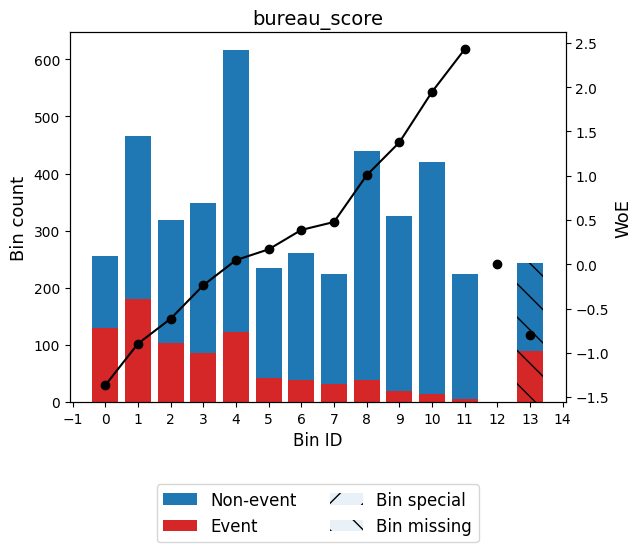

In [37]:
iv_table.plot(metric='woe')

#### Get WOE for Variable levels

In [38]:
X = train["purpose"]
y = train["bad"]

optbin = OptimalBinning(name = "purpose", dtype = "categorical")

optbin.fit(X, y)

OptimalBinning(dtype='categorical', name='purpose')

In [39]:
iv_table = optbin.binning_table
iv_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[LEASE],1458,0.333105,1170,288,0.197531,0.050268,0.000829,0.000104
1,[LOAN],2919,0.666895,2307,612,0.209661,-0.024559,0.000405,0.000051
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,4377,1.000000,3477,900,0.205620,,0.001234,0.000154


### 2. Information Value (IV) and Variable Selection
- how big is a 'big' differnce when looking across groups for WOE?
- IV measures how well the chraracteristic separates goods and bads
- IV > 0; bigger is better
- banking/credit ranges: <0.02 [not predictive], 0.02 < IV < 0.1 [weak predictor], 0.1 < IV < 0.25 [medium], 0.25 < IV < IV [strong]

In [40]:
X = train["bureau_score"]
y = train["bad"]

optbin = OptimalBinning(name = "bureau_score", dtype = "numerical")

optbin.fit(X, y)

OptimalBinning(name='bureau_score')

In [41]:
iv_table = optbin.binning_table
iv_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 606.50)",256,0.058488,127,129,0.503906,-1.367156,0.146023,0.016952
1,"[606.50, 640.50)",466,0.106466,285,181,0.388412,-0.897538,0.106936,0.012936
2,"[640.50, 653.50)",318,0.072653,215,103,0.323899,-0.615621,0.032388,0.003986
3,"[653.50, 667.50)",348,0.079507,262,86,0.247126,-0.237533,0.004799,0.000598
4,"[667.50, 689.50)",616,0.140736,494,122,0.198052,0.046984,0.000306,0.000038
5,"[689.50, 699.50)",234,0.053461,192,42,0.179487,0.168295,0.001439,0.000180
6,"[699.50, 708.50)",261,0.059630,222,39,0.149425,0.387585,0.007951,0.000988
7,"[708.50, 717.50)",224,0.051177,193,31,0.138393,0.477173,0.010051,0.001245
8,"[717.50, 739.50)",439,0.100297,401,38,0.086560,1.004845,0.073461,0.008815
9,"[739.50, 757.50)",326,0.074480,306,20,0.061350,1.376322,0.090541,0.010501


In [42]:
from optbinning import BinningProcess

colnames = list(train.columns[0:20])
X = train[colnames]

selection_criteria = {"iv": {"min": 0.1, "max": 1}}

bin_proc = BinningProcess(colnames, selection_criteria = selection_criteria, categorical_variables = ["bankruptcy", "purpose", "used_ind"])

iv_all = bin_proc.fit(X, y).summary()

iv_all[iv_all.columns[0:6]].sort_values(by = ["iv"], ascending = False)

,name,dtype,status,selected,n_bins,iv
10,bureau_score,numerical,OPTIMAL,True,12,0.851485
8,tot_rev_line,numerical,OPTIMAL,True,10,0.512358
9,rev_util,numerical,OPTIMAL,True,10,0.363525
4,age_oldest_tr,numerical,OPTIMAL,True,10,0.322788
2,tot_derog,numerical,OPTIMAL,True,6,0.244956
17,ltv,numerical,OPTIMAL,True,7,0.193756
3,tot_tr,numerical,OPTIMAL,True,8,0.187039
7,tot_rev_debt,numerical,OPTIMAL,True,5,0.114815
13,down_pyt,numerical,OPTIMAL,True,5,0.113488
18,tot_income,numerical,OPTIMAL,True,9,0.108861


#### **Note
- IV > 0.5 should be a flag
- IV >= 1 is likely a leaky variable
- If one variable has a very high Information Value, consider making multiple models, with and without the dominant

### Scorecard Creation
- primarily use Logistic Regression

In [43]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

from optbinning import BinningProcess

In [44]:
from optbinning import Scorecard

# first 21 columns
colnames = list(train.columns[0:20])
# predictors
X = train[colnames]
# response variable
y = train["bad"]

# information value is the selection criteria, cutoff is 0.1 IV
selection_criteria = {"iv": {"min": 0.1, "max": 1}}

# identify the categorical variables
bin_proc = BinningProcess(colnames, selection_criteria = selection_criteria, categorical_variables = ["bankruptcy", "purpose", "used_ind"])

# set the estimator as a logistic regression
estimator = LogisticRegression(solver = "lbfgs")

# four inputs to the function: binning process, the estimator (log regr,or lin regr), scaling method, scaling method params
scorecard = Scorecard(binning_process = bin_proc,
                                        estimator = estimator, 
                                        scaling_method = "pdo_odds",
                                        scaling_method_params = {"pdo": 20, 
                                        "scorecard_points": 600, "odds": 50}
                    )
# this is where we can take care of requirements to over/undersample, and correct for it. This dataset has a weight variable.
scorecard.fit(X, y, sample_weight = train["weight"])

Scorecard(binning_process=BinningProcess(categorical_variables=['bankruptcy',
                                                                'purpose',
                                                                'used_ind'],
                                         selection_criteria={'iv': {'max': 1,
                                                                    'min': 0.1}},
                                         variable_names=['bankruptcy', 'app_id',
                                                         'tot_derog', 'tot_tr',
                                                         'age_oldest_tr',
                                                         'tot_open_tr',
                                                         'tot_rev_tr',
                                                         'tot_rev_debt',
                                                         'tot_rev_line',
                                                         'rev_util',
                                                         'bureau_score',
                                                         'purch_price', 'msrp',
                                                         'down_pyt', 'purpose',
                                                         'loan_term',
                                                         'loan_amt', 'ltv',
                                                         'tot_income',
                                                         'used_ind']),
          estimator=LogisticRegression(), scaling_method='pdo_odds',
          scaling_method_params={'odds': 50, 'pdo': 20,
                                 'scorecard_points': 600})

##### Coefficicents from the Logistic Regression

In [45]:
scorecard.table(style = "detailed")

,Variable,Bin id,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Coefficient,Points
0,tot_derog,0,"(-inf, 0.50)",9099,0.522541,8816,283,0.031102,0.529368,0.116163,0.014353,-0.200562,54.555125
1,tot_derog,1,"[0.50, 1.50)",2702,0.155171,2555,147,0.054404,-0.054134,0.000466,0.000058,-0.200562,51.178400
2,tot_derog,2,"[1.50, 2.50)",1285,0.073795,1201,84,0.065370,-0.249415,0.005139,0.000641,-0.200562,50.048303
3,tot_derog,3,"[2.50, 3.50)",915,0.052547,855,60,0.065574,-0.252752,0.003763,0.000469,-0.200562,50.028997
4,tot_derog,4,"[3.50, 5.50)",1137,0.065296,1016,121,0.106420,-0.781670,0.056997,0.006949,-0.200562,46.968143
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,tot_income,6,"[2943.13, 4771.00)",5183,0.297702,4925,258,0.049778,0.039793,0.000463,0.000058,-0.363018,51.908483
7,tot_income,7,"[4771.00, 6554.17)",2446,0.140494,2341,105,0.042927,0.195046,0.004901,0.000612,-0.363018,53.534679
8,tot_income,8,"[6554.17, inf)",2912,0.167260,2825,87,0.029876,0.571029,0.042508,0.005243,-0.363018,57.472897
9,tot_income,9,Special,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-0.363018,51.491671


### Model Evaluation

##### WOE Approach

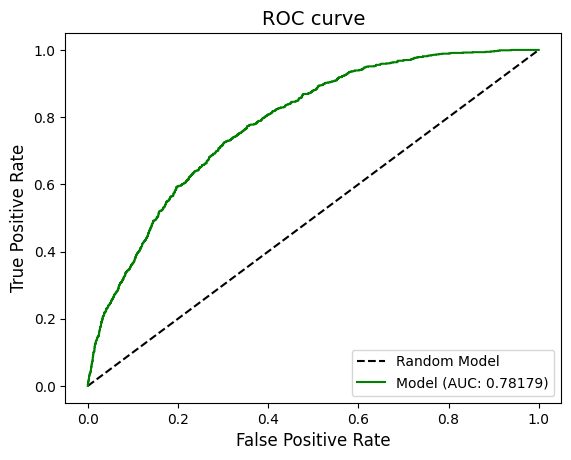

In [46]:
# Same as Log Regr: ROC and AUC, KS Statistic
from matplotlib import pyplot as plt
from optbinning.scorecard import plot_auc_roc, plot_ks

y_pred = scorecard.predict_proba(X)[:, 1]

plot_auc_roc(y, y_pred)

plt.show()

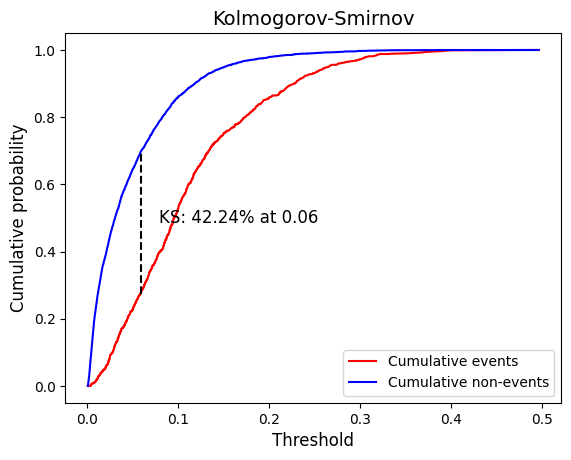

In [47]:
plot_ks(y, y_pred)

plt.show()

### Final Scorecard

In [48]:
# shows each variable, the bins, and the points assigned by category
scorecard.table(style = "summary")

,Variable,Bin,Points
0,tot_derog,"(-inf, 0.50)",54.555125
1,tot_derog,"[0.50, 1.50)",51.178400
2,tot_derog,"[1.50, 2.50)",50.048303
3,tot_derog,"[2.50, 3.50)",50.028997
4,tot_derog,"[3.50, 5.50)",46.968143
...,...,...,...
6,tot_income,"[2943.13, 4771.00)",51.908483
7,tot_income,"[4771.00, 6554.17)",53.534679
8,tot_income,"[6554.17, inf)",57.472897
9,tot_income,Special,51.491671


### Reject Inference

#### 1. Simple/Hard Cut Off Augmentation
- create predictions for the rejects dataset, based off our previous scorecard model
- this will give us insights (imperfect ones) into the rejects dataset, by the same metric we socred the accepts dataset
- then set the cutoff based on the Youden Index from the accepts dataset

In [49]:
X_r = rejects

rejects["y_pred"] = scorecard.predict_proba(X_r)[:, 1]

# add the target variable for the rejects dataset, as well as the weights (overweighting the 'goods' in this case). Same weighting in this case
rejects["bad"] = (rejects["y_pred"] > 0.06).astype(int) #Youden's index is the cutoff here
rejects["weight"] = rejects["bad"].apply(lambda x: 4.75 if x == 0 else 1)

rejects = rejects.drop("y_pred", axis=1)

# only took some of the rejects. We need a balanced dataset that looks like the sample pop - 70% accepted, 30% rejected
comb_hard = pd.concat([accepts, rejects.head(1876)], ignore_index=True)

#### 2. Parceling Augmentation
- create predictions for the rejects dataset, based off our previous scorecard model
- this will give us insights (imperfect ones) into the rejects dataset, by the same metric we socred the accepts dataset
- then randomly assign "good"/"bad" based on default ratio of that observation's probability bucket
    - example: P(default) = 0.03 for a Reject. Look at Default ratio for observations with that range in the Accepts dataset. Randomly apply that ratio to all observations in that bucket

#### 3. Fuzzy Augmentation
- create predictions for the rejects dataset, based off our previous scorecard model
- this will give us insights (imperfect ones) into the rejects dataset, by the same metric we socred the accepts dataset
- duplicate the 'rejects', apply weights to each obs based on probability of default. Good = 0.9, Bad = 0.1 for example.
    - works well with smaller reject inference dataset

### Visualize the Results
- decile plot
- control for weights throughout the process

In [50]:
test_final["score"] = scorecard.score(test_final)
test_final['decile'] = pd.qcut(test_final["score"], 10, labels = False)

PD = test_final[test_final['bad'] == 1].groupby('decile').size() / (test_final[test_final['bad'] == 0].groupby('decile').size() * 4.75 + test_final[test_final['bad'] == 1].groupby('decile').size())


plt.figure(figsize = (8, 6))
PD.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')
plt.axhline(y = 0.05, color = 'black', linestyle = '--', linewidth = 2)
plt.text(x = 9, y = 0.06, s = '5% Default', color = 'black', ha = 'right', va = 'bottom', fontsize = 12)

plt.title('Proportion of Default across Deciles of Score')
plt.xlabel('Decile')
plt.ylabel('Proportion of Default')
plt.xticks(rotation = 0)

NameError: name 'test_final' is not defined